# Optional Week 3 preview: Dynamic State-Transition MLP
# 선택 3주차 미리보기: 동적 상태전이 MLP

Surrogate Modeling for Process Prediction and Optimization
공정 예측과 최적화를 위한 서로게이트 모델링

This existing dynamic lab is preserved as an optional preview, outside the Week 2 required submission.
기존 동적 실습을 선택 미리보기로 보존했습니다. 2주차 필수 제출물에 포함하지 않습니다.


In [1]:
import argparse
import csv
import json
import platform
from pathlib import Path

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import torch
from torch import nn

LOWER = np.array([300.0, 1.0, 0.8])
UPPER = np.array([360.0, 10.0, 1.5])
SPECIES = ('A', 'B', 'C')
DT = 0.2
HORIZON = 30.0


def write_json(path, value):
    Path(path).write_text(json.dumps(value, indent=2, allow_nan=False) + '\n', encoding='utf-8')


def write_csv(path, header, rows):
    with Path(path).open('w', newline='', encoding='utf-8') as stream:
        writer = csv.writer(stream)
        writer.writerow(header)
        writer.writerows(rows)




## 1. Dynamic concentration balances / 동적 농도 수지

Inputs stay constant within each 0.2 min interval. Each trajectory keeps residence time and feed concentration fixed. Temperature changes between intervals.
각 0.2 min 구간에서 입력은 일정합니다. 궤적 안에서는 체류시간·유입 농도를 고정하고 온도를 바꿉니다.


In [2]:
def rate_constants(temperature):
    temperature = np.asarray(temperature, dtype=float)
    return (0.2 * np.exp(6000.0 * (1.0 / 330.0 - 1.0 / temperature)),
            0.1 * np.exp(5000.0 * (1.0 / 330.0 - 1.0 / temperature)))


def steady_state(inputs):
    """[T (K), tau (min), feed (mol/L)] -> [C_A, C_B, C_C] (mol/L)."""
    inputs = np.asarray(inputs, dtype=float)
    temperature, tau, feed = inputs.T
    k1, k2 = rate_constants(temperature)
    ca = feed / (1.0 + k1 * tau)
    cb = k1 * tau * ca / (1.0 + k2 * tau)
    cc = k2 * tau * cb
    return np.column_stack((ca, cb, cc))


def concentration_rate(states, controls):
    states, controls = np.asarray(states), np.asarray(controls)
    ca, cb, cc = states.T
    temperature, tau, feed = controls.T
    k1, k2 = rate_constants(temperature)
    return np.column_stack(((feed - ca) / tau - k1 * ca,
                            -cb / tau + k1 * ca - k2 * cb,
                            -cc / tau + k2 * cb))


def reference_step(states, controls, dt=DT):
    """Analytic concentration update with constant inputs over one interval."""
    states, controls = np.asarray(states, dtype=float), np.asarray(controls, dtype=float)
    equilibrium = steady_state(controls)
    k1, k2 = rate_constants(controls[:, 0])
    q = 1.0 / controls[:, 1]
    a, b = q + k1, q + k2
    ea, eb = np.exp(-a * dt), np.exp(-b * dt)
    difference = b - a
    coupling = np.empty_like(difference)
    regular = np.abs(difference) > 1e-10
    coupling[regular] = ea[regular] * (-np.expm1(-difference[regular] * dt)) / difference[regular]
    coupling[~regular] = dt * ea[~regular]
    ca = equilibrium[:, 0] + (states[:, 0] - equilibrium[:, 0]) * ea
    cb = (equilibrium[:, 1] + (states[:, 1] - equilibrium[:, 1]) * eb
          + k1 * (states[:, 0] - equilibrium[:, 0]) * coupling)
    total = controls[:, 2] + (states.sum(axis=1) - controls[:, 2]) * np.exp(-q * dt)
    return np.column_stack((ca, cb, total - ca - cb))




## 2. A six-input, three-output network / 입력 여섯 개·출력 세 개

Current A/B/C concentrations plus T, residence time, and feed concentration map to concentration increments. Add them to the current state.
현재 세 농도와 운전 조건에서 농도 변화량을 예측하고, 현재 농도에 더합니다.


In [3]:
def make_model(input_size):
    return nn.Sequential(nn.Linear(input_size, 32), nn.ReLU(),
                         nn.Linear(32, 32), nn.ReLU(), nn.Linear(32, 3))


def fit_mlp(x_train, y_train, x_val, y_val, *, seed=42, epochs=1400,
            batch_size=64, normalize_output=True, input_bounds=None):
    torch.set_num_threads(1)
    torch.manual_seed(seed)
    torch.use_deterministic_algorithms(True)
    if input_bounds is None:
        x_mean, x_scale = x_train.mean(axis=0), x_train.std(axis=0)
    else:
        lower, upper = input_bounds
        x_mean, x_scale = (lower + upper) / 2.0, (upper - lower) / 2.0
    x_scale = np.maximum(x_scale, 1e-8)
    y_mean = y_train.mean(axis=0) if normalize_output else np.zeros(3)
    y_scale = np.maximum(y_train.std(axis=0), 1e-8) if normalize_output else np.ones(3)
    train_x = torch.tensor((x_train - x_mean) / x_scale, dtype=torch.float32)
    train_y = torch.tensor((y_train - y_mean) / y_scale, dtype=torch.float32)
    val_x = torch.tensor((x_val - x_mean) / x_scale, dtype=torch.float32)
    val_y = torch.tensor((y_val - y_mean) / y_scale, dtype=torch.float32)
    model = make_model(x_train.shape[1])
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_function = nn.MSELoss()
    history, best_loss, best_epoch, best_weights = [], float('inf'), 0, None
    for epoch in range(1, epochs + 1):
        model.train()
        order = torch.randperm(len(train_x))
        for indices in order.split(batch_size):
            prediction = model(train_x[indices])
            loss = loss_function(prediction, train_y[indices])
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        model.eval()
        with torch.no_grad():
            train_loss = float(loss_function(model(train_x), train_y))
            val_loss = float(loss_function(model(val_x), val_y))
        history.append([epoch, train_loss, val_loss])
        if val_loss < best_loss:
            best_loss, best_epoch = val_loss, epoch
            best_weights = {key: value.detach().clone() for key, value in model.state_dict().items()}
        if epoch % 400 == 0:
            print(f'epoch {epoch}: train={train_loss:.6g}, validation={val_loss:.6g}')
        if epoch - best_epoch >= 180:
            break
    model.load_state_dict(best_weights)
    model.eval()
    scaling = {name: value.tolist() for name, value in
               [('x_mean', x_mean), ('x_scale', x_scale), ('y_mean', y_mean), ('y_scale', y_scale)]}
    scaling.update(input_size=x_train.shape[1], output_size=3, seed=seed,
                   best_epoch=best_epoch, trained_epochs=epoch, output_normalized=normalize_output)
    return model, scaling, np.asarray(history)


def predict(model, scaling, inputs):
    scaled = (np.asarray(inputs) - scaling['x_mean']) / scaling['x_scale']
    with torch.no_grad():
        result = model(torch.tensor(scaled, dtype=torch.float32)).numpy()
    return result * scaling['y_scale'] + scaling['y_mean']


def save_model(directory, name, model, scaling):
    torch.save(model.state_dict(), directory / f'{name}.pt')
    write_json(directory / f'{name}-scaling.json', scaling)


def load_model(directory, name):
    directory = Path(directory)
    scaling = json.loads((directory / f'{name}-scaling.json').read_text(encoding='utf-8'))
    model = make_model(scaling['input_size'])
    model.load_state_dict(torch.load(directory / f'{name}.pt', map_location='cpu', weights_only=True))
    model.eval()
    return model, scaling


def prediction_metrics(truth, prediction, feed):
    error = np.asarray(prediction) - np.asarray(truth)
    residual = np.asarray(prediction).sum(axis=-1) - feed
    return {'rmse_mol_L': np.sqrt(np.mean(error ** 2, axis=0)).tolist(),
            'balance_rmse_mol_L': float(np.sqrt(np.mean(residual ** 2))),
            'minimum_predicted_concentration_mol_L': float(np.min(prediction))}


def plot_history(history, path, title):
    fig, ax = plt.subplots(figsize=(7, 3.5))
    ax.semilogy(history[:, 0], history[:, 1], label='Train')
    ax.semilogy(history[:, 0], history[:, 2], label='Validation')
    ax.set(xlabel='Epoch', ylabel='Scaled MSE', title=title)
    ax.legend()
    fig.tight_layout()
    fig.savefig(path, dpi=160)
    plt.close(fig)




## 3. Trajectories, transition pairs, and rollout / 궤적·상태전이·rollout

Split complete trajectories into train/validation/test. One-step prediction uses reference current states; rollout uses its own previous predictions.
궤적 단위로 train·validation·test를 나눕니다. One-step에는 기준 현재 상태를, rollout에는 직전 예측을 넣습니다.


In [4]:
def simulate_trajectory(controls, initial, dt=DT):
    states = np.empty((len(controls) + 1, 3))
    states[0] = initial
    for k, control in enumerate(controls):
        states[k + 1] = reference_step(states[k:k + 1], control[None, :], dt)[0]
    return states


def generate_trajectories(seed=42):
    rng = np.random.default_rng(seed + 100)
    trajectories, identity = {}, 0
    count = int(round(HORIZON / DT))
    for split, size in [('train', 60), ('validation', 15), ('test', 20)]:
        group = []
        for i in range(size):
            tau, feed = rng.uniform(1, 10), rng.uniform(0.8, 1.5)
            temperatures = np.repeat(rng.uniform(300, 360, 6), count // 6)
            initial = np.array([feed, 0., 0.]) if rng.random() < 0.5 else feed * rng.dirichlet(np.ones(3))
            if split == 'test' and i < 2:
                tau, feed, initial = 5.0, 1.2, np.array([1.2, 0., 0.])
                temperatures[:] = 330.0
                if i == 1:
                    temperatures[int(round(10.0 / DT)):] = 345.0
            controls = np.column_stack((temperatures, np.full(count, tau), np.full(count, feed)))
            group.append({'id': identity, 'controls': controls, 'states': simulate_trajectory(controls, initial)})
            identity += 1
        trajectories[split] = group
    return trajectories


def transition_data(group):
    inputs = np.concatenate([np.column_stack((t['states'][:-1], t['controls'])) for t in group])
    deltas = np.concatenate([np.diff(t['states'], axis=0) for t in group])
    return inputs, deltas


def dynamic_step(model, scaling, states, controls):
    return np.asarray(states) + predict(model, scaling, np.column_stack((states, controls)))


def rollout(model, scaling, controls, initial):
    states = np.empty((len(controls) + 1, 3))
    states[0] = initial
    for k, control in enumerate(controls):
        states[k + 1] = dynamic_step(model, scaling, states[k:k + 1], control[None, :])[0]
    return states


def dynamic_figures(directory, trajectories, predictions, one_step_rmse):
    time = np.arange(int(round(HORIZON / DT)) + 1) * DT
    fig, axes = plt.subplots(4, 1, figsize=(8, 7.4), sharex=True)
    colors = ['#0b6b57', '#cf7a20', '#244a7f']
    for i, label in [(0, '330 K constant'), (1, '330 to 345 K at 10 min')]:
        trajectory = trajectories[i]
        axes[0].step(time[:-1], trajectory['controls'][:, 0], where='post', label=label)
        for j in range(3):
            color = colors[i]
            axes[j + 1].plot(time, trajectory['states'][:, j], color=color, label=f'{label}: reference')
            axes[j + 1].plot(time, predictions[i][:, j], '--', color=color, label=f'{label}: MLP')
    axes[0].set(ylabel='T (K)', title='Future temperature inputs and concentration rollout')
    axes[0].legend(fontsize=7)
    for j in range(3):
        axes[j + 1].set(ylabel=f'C_{SPECIES[j]} (mol/L)')
    axes[1].legend(fontsize=7, ncol=2)
    axes[-1].set(xlabel='Time (min)')
    fig.tight_layout()
    fig.savefig(directory / 'dynamic-rollout.png', dpi=160)
    plt.close(fig)
    error = np.stack([pred - t['states'] for pred, t in zip(predictions, trajectories)])
    rmse_by_time = np.sqrt(np.mean(error ** 2, axis=0))
    residuals = np.stack([pred.sum(axis=1) - t['controls'][0, 2] for pred, t in zip(predictions, trajectories)])
    fig, axes = plt.subplots(2, 1, figsize=(7, 5.2), sharex=True)
    for j, color in enumerate(colors):
        axes[0].plot(time, rmse_by_time[:, j], color=color, label=f'{SPECIES[j]} rollout')
        axes[0].axhline(one_step_rmse[j], color=color, linestyle=':', alpha=0.7)
    axes[0].set(ylabel='RMSE (mol/L)', title='Rollout errors; dotted lines show one-step RMSE')
    axes[0].legend(fontsize=8, ncol=3)
    axes[1].plot(time, np.sqrt(np.mean(residuals ** 2, axis=0)), color='#0b6b57')
    axes[1].set(xlabel='Time (min)', ylabel='Balance RMSE (mol/L)')
    fig.tight_layout()
    fig.savefig(directory / 'dynamic-errors.png', dpi=160)
    plt.close(fig)


def run_dynamic(directory, seed=42, epochs=800):
    directory = Path(directory)
    directory.mkdir(parents=True, exist_ok=True)
    trajectories = generate_trajectories(seed)
    train_x, train_delta = transition_data(trajectories['train'])
    val_x, val_delta = transition_data(trajectories['validation'])
    test_x, test_delta = transition_data(trajectories['test'])
    model, scaling, history = fit_mlp(train_x, train_delta, val_x, val_delta, seed=seed,
                                    epochs=epochs, batch_size=512)
    scaling.update(target='concentration_increment', dt_min=DT)
    one_step = dynamic_step(model, scaling, test_x[:, :3], test_x[:, 3:])
    truth = test_x[:, :3] + test_delta
    predictions = [rollout(model, scaling, t['controls'], t['states'][0]) for t in trajectories['test']]
    joined_truth = np.concatenate([t['states'][1:] for t in trajectories['test']])
    joined_predictions = np.concatenate([p[1:] for p in predictions])
    joined_feed = np.concatenate([t['controls'][:, 2] for t in trajectories['test']])
    one_metrics = prediction_metrics(truth, one_step, test_x[:, 5])
    rollout_metrics = prediction_metrics(joined_truth, joined_predictions, joined_feed)
    metrics = {'one_step': one_metrics, 'rollout': rollout_metrics,
               'trajectory_counts': {key: len(value) for key, value in trajectories.items()},
               'transition_counts': {key: sum(len(t['controls']) for t in value) for key, value in trajectories.items()},
               'best_epoch': scaling['best_epoch'], 'trained_epochs': scaling['trained_epochs'],
               'dt_min': DT, 'horizon_min': HORIZON, 'seed': seed,
               'temperature_plans': [{'name': name,
                                      'reference_final_C_B': float(trajectories['test'][i]['states'][-1, 1]),
                                      'predicted_final_C_B': float(predictions[i][-1, 1])}
                                     for i, name in enumerate(['constant_330_K', 'step_330_to_345_K'])]}
    save_model(directory, 'dynamic-model', model, scaling)
    write_json(directory / 'dynamic-results.json', metrics)
    write_csv(directory / 'dynamic-training.csv', ['epoch', 'train_scaled_mse', 'validation_scaled_mse'], history)
    write_csv(directory / 'dynamic-dataset.csv',
              ['split', 'trajectory_id', 'time_min', 'T_K', 'tau_min', 'feed_mol_L',
               'C_A', 'C_B', 'C_C', 'next_C_A', 'next_C_B', 'next_C_C'],
              ([split, t['id'], k * DT, *control, *t['states'][k], *t['states'][k + 1]]
               for split, group in trajectories.items() for t in group for k, control in enumerate(t['controls'])))
    write_csv(directory / 'dynamic-comparison.csv',
              ['plan', 'time_min', 'reference_C_A', 'reference_C_B', 'reference_C_C', 'MLP_C_A', 'MLP_C_B', 'MLP_C_C'],
              ([i, k * DT, *truth, *prediction] for i in range(2)
               for k, (truth, prediction) in enumerate(zip(trajectories['test'][i]['states'], predictions[i]))))
    plot_history(history, directory / 'dynamic-training.png', 'Dynamic increment MLP training')
    dynamic_figures(directory, trajectories['test'], predictions, one_metrics['rmse_mol_L'])
    print(json.dumps(metrics, indent=2))
    return metrics




In [5]:
dynamic_metrics = run_dynamic(Path("week02-results"), seed=42)


epoch 400: train=0.00193246, validation=0.00811099
epoch 800: train=0.00127848, validation=0.00652691
{
  "one_step": {
    "rmse_mol_L": [
      0.0011698733687232174,
      0.0012881459751205937,
      0.0011631600085516736
    ],
    "balance_rmse_mol_L": 5.1329873751630126e-05,
    "minimum_predicted_concentration_mol_L": -0.001152203213085274
  },
  "rollout": {
    "rmse_mol_L": [
      0.009465025357851294,
      0.009629144427021242,
      0.010425194376398996
    ],
    "balance_rmse_mol_L": 0.002013982987355719,
    "minimum_predicted_concentration_mol_L": -0.00516641000457166
  },
  "trajectory_counts": {
    "train": 60,
    "validation": 15,
    "test": 20
  },
  "transition_counts": {
    "train": 9000,
    "validation": 2250,
    "test": 3000
  },
  "best_epoch": 758,
  "trained_epochs": 800,
  "dt_min": 0.2,
  "horizon_min": 30.0,
  "seed": 42,
  "temperature_plans": [
    {
      "name": "constant_330_K",
      "reference_final_C_B": 0.4000913547884453,
      "predicte

### Training loss / 학습 loss


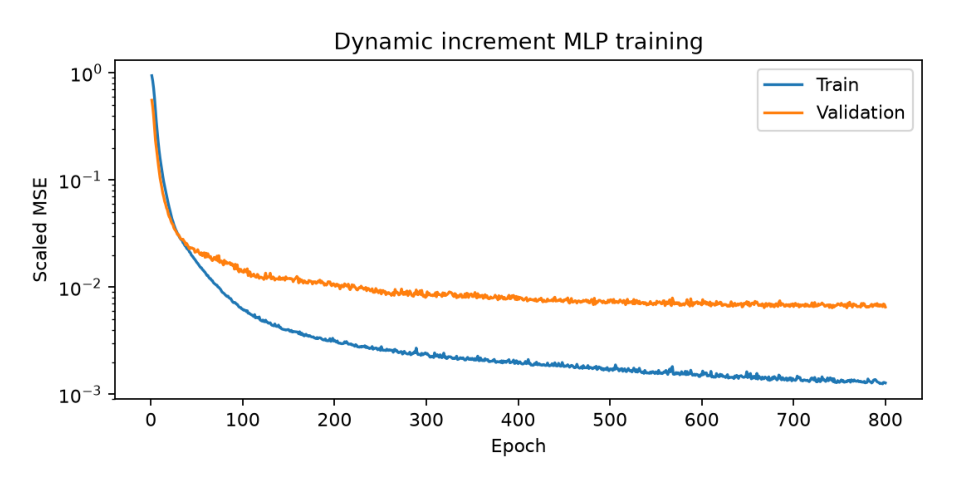

In [6]:
figure = plt.figure(figsize=(10, 7))
plt.imshow(plt.imread(Path("week02-results") / "dynamic-training.png"))
plt.axis("off")
plt.show()


### Two temperature plans / 두 온도 계획


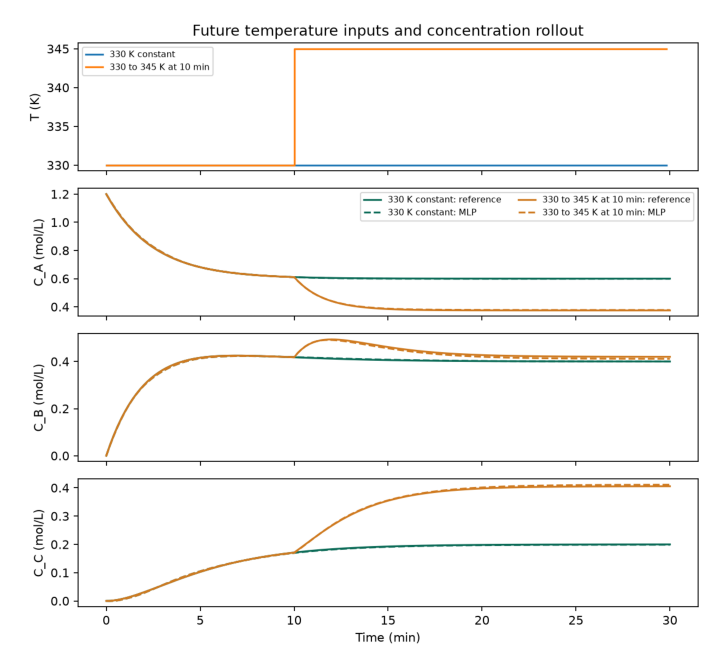

In [7]:
figure = plt.figure(figsize=(10, 7))
plt.imshow(plt.imread(Path("week02-results") / "dynamic-rollout.png"))
plt.axis("off")
plt.show()


### Errors over time / 시간에 따른 오차


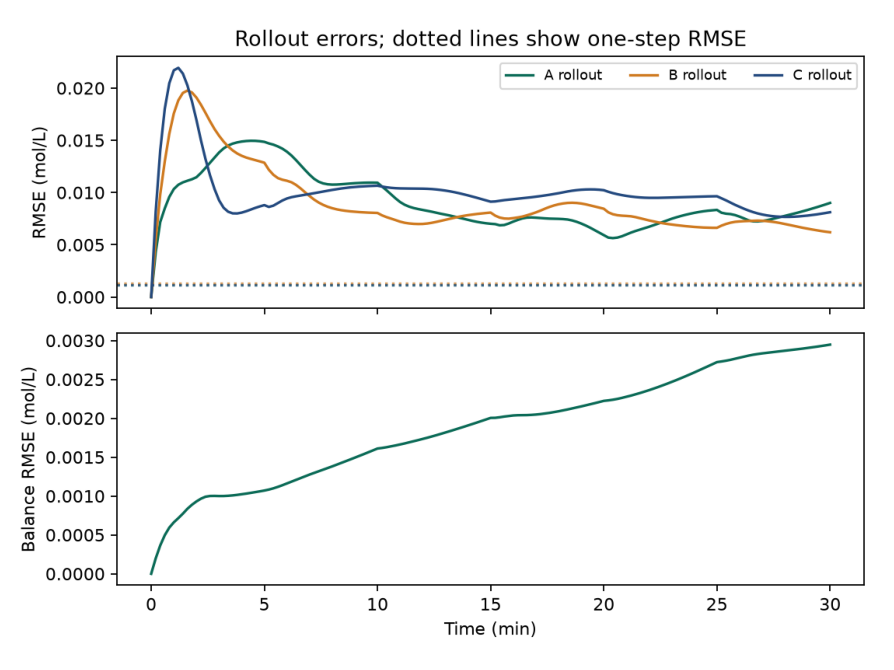

In [8]:
figure = plt.figure(figsize=(10, 7))
plt.imshow(plt.imread(Path("week02-results") / "dynamic-errors.png"))
plt.axis("off")
plt.show()


## Exercises / 연습문제

1. Count N input intervals and N+1 concentration times. / 입력 N개·출력 시점 N+1개를 확인하세요.
2. Compare one-step and rollout errors for each species. / 성분별 one-step·rollout 오차를 비교하세요.
3. Change the temperature-step time and compare B trajectories. / 온도 step 시점을 바꾸어 B 농도를 비교하세요.
4. Compute concentration-sum residuals along both predicted trajectories. / 두 예측 궤적의 농도 합 residual을 계산하세요.
